In [1]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from IPython.display import Image, display
from typing import Literal
from langgraph.prebuilt import ToolNode

In [2]:
class Exam(BaseModel):
  score: int
  result: str = ""

In [3]:
def pass_exam(_state: Exam) -> dict:
  return {
    "result": "PASS 🎊"
  }

def fail_exam(_state: Exam) -> dict:
  return {
    "result": "FAIL 📚"
  }

def router(state: Exam) -> Literal["pass_exam", "fail_exam"]:
  return "pass_exam" if state.score >= 6 else "fail_exam"

In [4]:
exam_graph = (
  StateGraph(Exam)
  .add_node("pass_exam", pass_exam)
  .add_node("fail_exam", fail_exam)
  .add_conditional_edges(START, router)
  .compile()
)

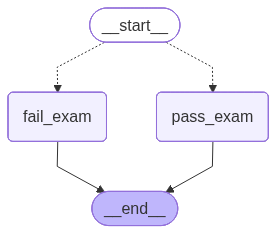

In [5]:
display(Image(exam_graph.get_graph().draw_mermaid_png()))

In [6]:
exam = exam_graph.invoke({ "score": 7 })

In [7]:
exam

{'score': 7, 'result': 'PASS 🎊'}